<a href="https://colab.research.google.com/github/Gutavo2000/LCE0212---Estat-stica-Aplicada-s-Ci-ncias-dos-Alimentos/blob/main/tarefa11_variaveis_aleatorias_alimento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 11: Variáveis Aleatórias em Ciências dos Alimentos

Este notebook apresenta e exemplifica conceitos introdutórios de Probabilidade, com foco em variáveis aleatórias, e a aplicação dos modelos de Bernoulli, Binomial e Poisson, todos contextualizados em situações observáveis nas Ciências dos Alimentos.

**Integrantes do Grupo:**
- Gustavo Gabriel da Silva Rodrigues Bruno Nº 11373741
- Henrique de Angelo Silva Nº 17896022
- Luciana Gouveia dos Santos Nº 15472401

---

## 1. Variável Aleatória

Uma **variável aleatória** é uma função que associa um valor numérico a cada resultado de um experimento aleatório. Em outras palavras, é uma descrição numérica de um fenômeno cujo resultado é incerto, mas cujas probabilidades dos diferentes resultados podem ser determinadas. Ela nos permite quantificar os resultados de eventos aleatórios.

### Exemplo em Ciências dos Alimentos: Número de Embalagens Defeituosas

Considere o experimento aleatório de inspecionar um lote de 100 embalagens de um produto alimentício. A variável aleatória de interesse pode ser o **número de embalagens defeituosas** encontradas nesse lote. Os possíveis resultados para essa variável seriam 0, 1, 2, ..., até 100.



In [1]:
import numpy as np
import pandas as pd
from scipy.stats import bernoulli, binom, poisson
import matplotlib.pyplot as plt
import seaborn as sns

# Simulação de um experimento aleatório
# Vamos simular a inspeção de 100 embalagens, onde cada embalagem tem 5% de chance de ser defeituosa.
np.random.seed(42) # para reprodutibilidade

numero_total_embalagens = 100
prob_defeito_por_embalagem = 0.05

# Simulamos se cada embalagem é defeituosa (1) ou não (0)
resultados_inspecao = np.random.choice([0, 1], size=numero_total_embalagens, p=[1 - prob_defeito_por_embalagem, prob_defeito_por_embalagem])

# A variável aleatória 'Número de Embalagens Defeituosas' é a soma dos resultados
numero_embalagens_defeituosas = np.sum(resultados_inspecao)

print(f"Em um lote de {numero_total_embalagens} embalagens, foram encontradas {numero_embalagens_defeituosas} embalagens defeituosas.")
print(f"Resultados da inspeção (1 para defeito, 0 para não defeito, primeiras 10 embalagens): {resultados_inspecao[:10]}")

Em um lote de 100 embalagens, foram encontradas 5 embalagens defeituosas.
Resultados da inspeção (1 para defeito, 0 para não defeito, primeiras 10 embalagens): [0 1 0 0 0 0 0 0 0 0]


# Interpretação Variável Aleatória
Nesta simulação, foram encontradas 5 embalagens defeituosas em um lote de 100 unidades. Isso exemplifica uma variável aleatória discreta, pois o número de embalagens defeituosas pode assumir apenas valores inteiros entre 0 e 100.

---
## 2. Variáveis Aleatórias Discretas e Contínuas

Variáveis aleatórias são classificadas em discretas ou contínuas, dependendo do conjunto de valores que podem assumir.

### Variáveis Aleatórias Discretas

Uma **variável aleatória discreta** é aquela que pode assumir um número finito ou contável de valores. Geralmente, esses valores são inteiros e resultam de uma contagem.

**Exemplos em Ciências dos Alimentos:**

1.  **Número de reclamações de consumidores por dia:** Os valores possíveis são 0, 1, 2, 3, ..., que são contáveis e inteiros. Não é possível ter 1.5 reclamações.
2.  **Número de frutas danificadas em uma caixa:** Semelhante ao exemplo de embalagens defeituosas, a contagem de frutas danificadas (0, 1, 2, ...) é um valor inteiro e contável.
3.  **Número de colônias de bactérias em uma placa de Petri:** Após a incubação, a contagem de colônias resulta em números inteiros (0, 1, 2, ...). Não se pode ter uma fração de uma colônia.

### Variáveis Aleatórias Contínuas

Uma **variável aleatória contínua** é aquela que pode assumir qualquer valor em um intervalo contínuo de números reais. Geralmente, esses valores resultam de uma medição e podem incluir frações ou decimais.

**Exemplos em Ciências dos Alimentos:**

1.  **Massa de um produto alimentício (em gramas):** A massa pode ser 250.0 g, 250.1 g, 250.05 g, etc., dependendo da precisão da balança. Os valores podem variar continuamente em um intervalo.
2.  **Teor de umidade de um alimento (em %):** O teor de umidade pode ser 15.3%, 15.35%, 15.357%, etc. É uma medida que pode ter infinitos valores em um determinado intervalo.
3.  **Temperatura de armazenamento de um refrigerador (em °C):** A temperatura pode ser 4.0 °C, 4.1 °C, 4.05 °C. É um valor que pode variar continuamente e ser medido com diferentes níveis de precisão.

---
## 3. Modelo de Bernoulli

O **modelo de Bernoulli** descreve experimentos aleatórios que têm apenas dois resultados possíveis: 'sucesso' ou 'fracasso'. A probabilidade de 'sucesso' é denotada por $p$, e a probabilidade de 'fracasso' é $1-p$.

### Exemplo em Ciências dos Alimentos: Embalagem Aprovada ou Reprovada

Considere a inspeção de uma única embalagem de um alimento quanto à sua selagem. O experimento tem dois resultados:

*   **Sucesso:** A embalagem está com a selagem **aprovada**.
*   **Fracasso:** A embalagem está com a selagem **reprovada**.

Vamos assumir que a probabilidade de uma embalagem ser aprovada ($p$) é de 0.98.



In [2]:
# Parâmetro da distribuição de Bernoulli
p_aprovacao = 0.98 # Probabilidade de sucesso (embalagem aprovada)

# Criação de uma variável aleatória de Bernoulli
bernoulli_rv = bernoulli(p_aprovacao)

# Simulando um único ensaio (inspeção de uma embalagem)
resultado_inspecao = bernoulli_rv.rvs(size=1)[0]

if resultado_inspecao == 1:
    print(f"Simulação Bernoulli: A embalagem foi APROVADA (probabilidade de {p_aprovacao*100}% de aprovação).")
else:
    print(f"Simulação Bernoulli: A embalagem foi REPROVADA (probabilidade de {(1-p_aprovacao)*100}% de reprovação).")

# Calculando a probabilidade de aprovação e reprovação
prob_aprovar = bernoulli_rv.pmf(1) # Probabilidade de X=1 (sucesso)
prob_reprovar = bernoulli_rv.pmf(0) # Probabilidade de X=0 (fracasso)

print(f"Probabilidade teórica de aprovação: {prob_aprovar:.2f}")
print(f"Probabilidade teórica de reprovação: {prob_reprovar:.2f}")

Simulação Bernoulli: A embalagem foi APROVADA (probabilidade de 98.0% de aprovação).
Probabilidade teórica de aprovação: 0.98
Probabilidade teórica de reprovação: 0.02


#Interpretação Modelo de Bernoulli
A probabilidade de uma embalagem ser aprovada quanto à selagem é de 98%, enquanto a probabilidade de reprovação é de 2%. Como o experimento considera apenas uma embalagem e apresenta dois resultados possíveis, aprovado ou reprovado, ele pode ser representado por uma distribuição de Bernoulli.

---
## 4. Modelo Binomial

O **modelo Binomial** é utilizado para descrever o número de sucessos em uma série fixa de experimentos de Bernoulli independentes. Ele se aplica quando as seguintes características são satisfeitas:

1.  **Número fixo de observações (n):** O experimento é repetido um número definido de vezes.
2.  **Dois resultados possíveis em cada observação:** Cada repetição tem um resultado de 'sucesso' ou 'fracasso'.
3.  **Probabilidade de sucesso constante (p):** A probabilidade de sucesso é a mesma para cada observação.
4.  **Observações independentes:** O resultado de uma observação não afeta o resultado das outras.

### Exemplo em Ciências dos Alimentos: Número de Embalagens Defeituosas em uma Amostra

Continuando com o exemplo da selagem de embalagens, se inspecionarmos uma amostra de 20 embalagens (n=20) e a probabilidade de uma única embalagem ser defeituosa (fracasso no contexto anterior, mas agora 'sucesso' se considerarmos a contagem de defeitos) é de 0.02 (p=0.02). Queremos saber a probabilidade de encontrar um certo número de embalagens defeituosas nessa amostra.



Em uma amostra de 20 embalagens, foram encontradas 0 embalagens defeituosas (simulação).
Probabilidade de encontrar exatamente 1 embalagem defeituosa: 0.2725
Probabilidade de encontrar no máximo 2 embalagens defeituosas: 0.9929


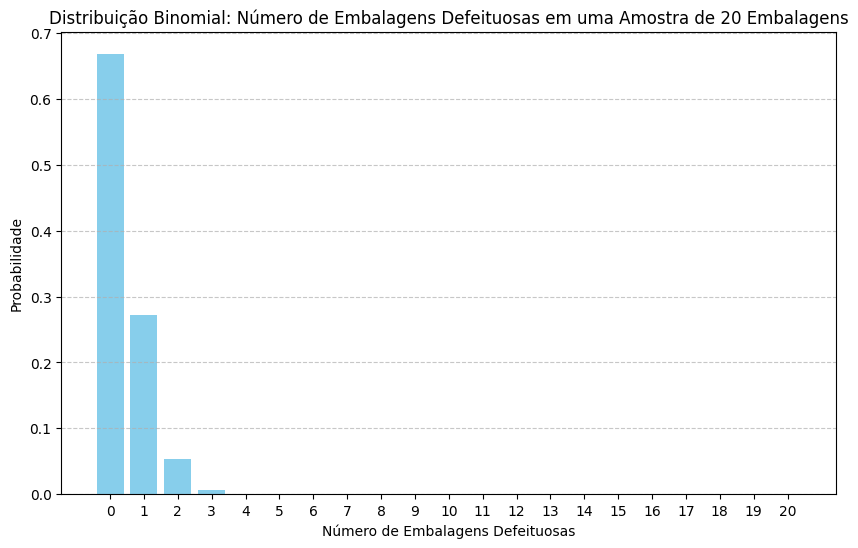

In [6]:
# Parâmetros da distribuição Binomial
n_ensaios = 20 # Número de embalagens na amostra
p_defeito = 0.02 # Probabilidade de uma embalagem ser defeituosa

# Criação de uma variável aleatória Binomial
binomial_rv = binom(n=n_ensaios, p=p_defeito)

# Simulando o número de embalagens defeituosas em uma amostra de 20
numero_defeituosas_simulado = binomial_rv.rvs(size=1)[0]
print(f"Em uma amostra de {n_ensaios} embalagens, foram encontradas {numero_defeituosas_simulado} embalagens defeituosas (simulação).")

# Calculando a probabilidade de encontrar exatamente 1 embalagem defeituosa
prob_exatamente_1_defeito = binomial_rv.pmf(1)
print(f"Probabilidade de encontrar exatamente 1 embalagem defeituosa: {prob_exatamente_1_defeito:.4f}")

# Calculando a probabilidade de encontrar no máximo 2 embalagens defeituosas (0, 1 ou 2)
prob_max_2_defeitos = binomial_rv.cdf(2)
print(f"Probabilidade de encontrar no máximo 2 embalagens defeituosas: {prob_max_2_defeitos:.4f}")

# Geração de um gráfico da PMF (Função de Massa de Probabilidade)
x = np.arange(0, n_ensaios + 1)
plt.figure(figsize=(10, 6))
plt.bar(x, binomial_rv.pmf(x), color='skyblue')
plt.title('Distribuição Binomial: Número de Embalagens Defeituosas em uma Amostra de 20 Embalagens')
plt.xlabel('Número de Embalagens Defeituosas')
plt.ylabel('Probabilidade')
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#Interpretação Modelo Binomial
Considerando uma amostra de 20 embalagens e uma probabilidade de defeito de 2% para cada unidade, a probabilidade de encontrar exatamente uma embalagem defeituosa é de aproximadamente 27,25%. Já a probabilidade de encontrar no máximo duas embalagens defeituosas é de aproximadamente 99,29%. Isso indica que, nessas condições, é muito provável que a amostra apresente zero, uma ou duas embalagens defeituosas.

---
## 5. Modelo de Poisson

O **modelo de Poisson** é usado para modelar o número de ocorrências de um evento em um intervalo fixo de tempo ou espaço, quando esses eventos ocorrem com uma taxa média constante e são independentes entre si. É especialmente útil para eventos raros.

O único parâmetro da distribuição de Poisson é $\lambda$ (lambda), que representa a taxa média de ocorrências no intervalo especificado.

### Exemplo em Ciências dos Alimentos: Número de Falhas em uma Linha de Envase por Hora

Considere uma linha de envase de produtos alimentícios. O número de falhas (por exemplo, garrafas caídas, máquina travada) que ocorrem em uma hora pode ser modelado pela distribuição de Poisson. Suponha que, em média, ocorram 3 falhas por hora ($\lambda = 3$).




Em uma hora, a linha de envase apresentou 3 falhas (simulação).
Probabilidade de ocorrer exatamente 2 falhas em uma hora: 0.2240
Probabilidade de ocorrer no máximo 1 falha em uma hora: 0.1991


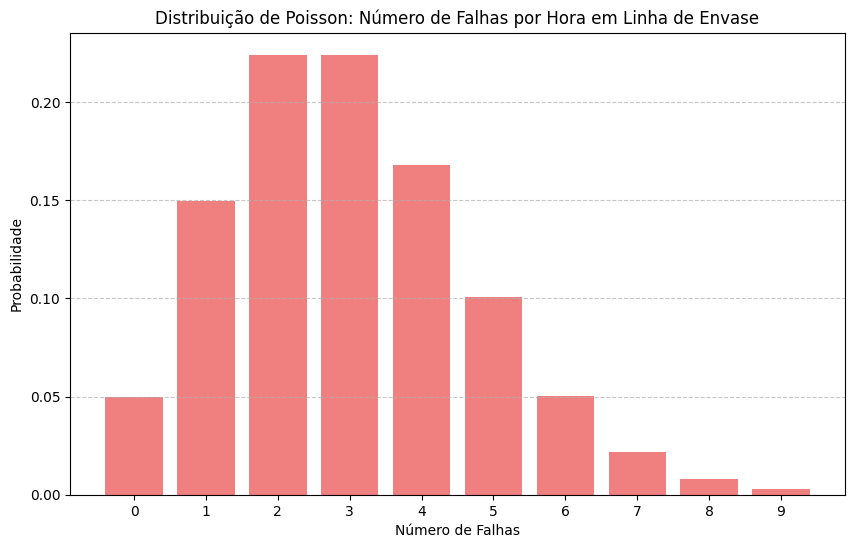

In [4]:
# Parâmetro da distribuição de Poisson
lambda_media_falhas = 3 # Média de falhas por hora

# Criação de uma variável aleatória de Poisson
poisson_rv = poisson(mu=lambda_media_falhas)

# Simulando o número de falhas em uma hora
numero_falhas_simulado = poisson_rv.rvs(size=1)[0]
print(f"Em uma hora, a linha de envase apresentou {numero_falhas_simulado} falhas (simulação).")

# Calculando a probabilidade de ter exatamente 2 falhas em uma hora
prob_exatamente_2_falhas = poisson_rv.pmf(2)
print(f"Probabilidade de ocorrer exatamente 2 falhas em uma hora: {prob_exatamente_2_falhas:.4f}")

# Calculando a probabilidade de ter no máximo 1 falha em uma hora
prob_max_1_falha = poisson_rv.cdf(1)
print(f"Probabilidade de ocorrer no máximo 1 falha em uma hora: {prob_max_1_falha:.4f}")

# Geração de um gráfico da PMF (Função de Massa de Probabilidade)
x = np.arange(0, 10) # Intervalo razoável para o número de falhas
plt.figure(figsize=(10, 6))
plt.bar(x, poisson_rv.pmf(x), color='lightcoral')
plt.title('Distribuição de Poisson: Número de Falhas por Hora em Linha de Envase')
plt.xlabel('Número de Falhas')
plt.ylabel('Probabilidade')
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#Interpretação Modelo de Poisson
Considerando uma média de 3 falhas por hora na linha de envase, a probabilidade de ocorrerem exatamente duas falhas em uma hora é de aproximadamente 22,40%. Já a probabilidade de ocorrer no máximo uma falha nesse período é de aproximadamente 19,91%. O modelo de Poisson permite, portanto, estimar a probabilidade de diferentes quantidades de falhas ao longo de um intervalo de tempo.

---
## 6. Comparação dos Modelos: Bernoulli, Binomial e Poisson

Para facilitar a compreensão das diferenças e aplicações de cada modelo, apresentamos uma tabela comparativa:


In [5]:
comparacao_data = {
    "Modelo": ["Bernoulli", "Binomial", "Poisson"],
    "Tipo de Fenômeno Representado": [
        "Resultado de um único ensaio com duas categorias (sucesso/fracasso)",
        "Número de sucessos em uma série fixa de ensaios independentes de Bernoulli",
        "Número de ocorrências de um evento em um intervalo fixo (tempo/espaço)"
    ],
    "Possíveis Valores da Variável": [
        "0 ou 1 (fracasso ou sucesso)",
        "0, 1, 2, ..., n (onde n é o número total de ensaios)",
        "0, 1, 2, 3, ... (número inteiro não negativo)"
    ],
    "Situação de Aplicabilidade": [
        "Um único evento dicotômico (ex: produto aprovado/reprovado)",
        "Múltiplos eventos dicotômicos com n fixo e p constante (ex: número de defeitos em uma amostra)",
        "Contagem de eventos raros em um intervalo contínuo (ex: número de falhas por hora, reclamações por dia)"
    ],
    "Exemplo em Ciências dos Alimentos": [
        "Uma fruta está com ou sem dano visível.",
        "Número de consumidores que aprovam um novo sabor de iogurte em uma pesquisa com 50 pessoas.",
        "Número de contaminações por lote de produção de um alimento."
    ]
}

df_comparacao = pd.DataFrame(comparacao_data)
df_comparacao.set_index('Modelo', inplace=True)
display(df_comparacao)


,Tipo de Fenômeno Representado,Possíveis Valores da Variável,Situação de Aplicabilidade,Exemplo em Ciências dos Alimentos
Modelo,,,,
Bernoulli,Resultado de um único ensaio com duas categori...,0 ou 1 (fracasso ou sucesso),Um único evento dicotômico (ex: produto aprova...,Uma fruta está com ou sem dano visível.
Binomial,Número de sucessos em uma série fixa de ensaio...,"0, 1, 2, ..., n (onde n é o número total de en...",Múltiplos eventos dicotômicos com n fixo e p c...,Número de consumidores que aprovam um novo sab...
Poisson,Número de ocorrências de um evento em um inter...,"0, 1, 2, 3, ... (número inteiro não negativo)",Contagem de eventos raros em um intervalo cont...,Número de contaminações por lote de produção d...


---
## 7. Requisitos Técnicos e Conclusão

Este script foi desenvolvido para ser claro, organizado e executável em ambiente Python. Foram utilizados comentários para explicar os principais blocos de código e as escolhas realizadas.

*   **Nomes de variáveis:** Buscou-se utilizar nomes claros e coerentes, como `p_aprovacao`, `n_ensaios`, `lambda_media_falhas`.
*   **Mensagens e resultados:** As saídas foram formatadas para serem compreensíveis, com explicações sobre os valores gerados.
*   **Organização:** O notebook está dividido em seções claras usando títulos Markdown para facilitar a navegação.
*   **Exemplos numéricos e interpretações:** Todos os modelos foram acompanhados de exemplos numéricos e suas respectivas interpretações contextualizadas nas Ciências dos Alimentos.
*   **Bibliotecas:** Foram utilizadas as bibliotecas `numpy`, `pandas`, `scipy.stats`, `matplotlib` e `seaborn`, que são padrões para análise de dados e probabilidade em Python.
    *   `numpy`: Para operações numéricas e geração de dados.
    *   `pandas`: Para estruturação e exibição de dados (e.g., tabela de comparação).
    *   `scipy.stats`: Para as funções de distribuições de probabilidade (Bernoulli, Binomial, Poisson).
    *   `matplotlib` e `seaborn`: Para visualização das distribuições.

Este trabalho visa fornecer uma base sólida para a compreensão dos conceitos de variáveis aleatórias e das principais distribuições de probabilidade em um contexto prático e relevante para as Ciências dos Alimentos. O código é funcional e permite a execução e análise por outros usuários com conhecimentos básicos de Python.

### Referências Bibliográficas e Fontes de Dados

*   **Dados:** Os dados utilizados neste trabalho são simulados. A simulação foi escolhida por permitir controlar os parâmetros dos modelos probabilísticos e demonstrar de forma didática o comportamento das distribuições de Bernoulli, Binomial e Poisson em situações hipotéticas relacionadas às Ciências dos Alimentos. Os valores não representam dados provenientes de uma indústria específica.
*   **Conceitos de Probabilidade:**
    *   Montgomery, D. C., & Runger, G. C. (2018). *Estatística Aplicada e Probabilidade para Engenheiros*. LTC.
    *   Morettin, P. A., & Bussab, W. O. (2017). *Estatística Básica*. Saraiva Educação.
*   **Documentação das Bibliotecas Python:**
    *   [NumPy Documentation](https://numpy.org/doc/)
    *   [Pandas Documentation](https://pandas.pydata.org/docs/)
    *   [SciPy Stats Documentation](https://docs.scipy.org/doc/scipy/reference/stats.html)
    *   [Matplotlib Documentation](https://matplotlib.org/stable/contents.html)
    
